In [1]:
import sys
sys.path.append("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork")

from IPython.display import display, HTML, Markdown
import murraylab_tools.echo as mt_echo
import os.path
import pandas as pd
from murraylab_tools.echo.echo_functions import echo_round
import os.path
import math
import matplotlib.pyplot as plt

import os

import numpy as np


In [2]:
dms_input_df = pd.read_csv("/resnick/groups/shapirolab/idev/data/semper_mutate/tests/data/20241207_rluc_dms_input.csv")
Rluc_AA = 'MTSKVYDPEQRKRMITGPQWWARCKQMNVLDSFINYYDSEKHAENAVIFLHGNAASSYLWRHVVPHIEPVARCIIPDLIGMGKSGKSGNGSYRLLDHYKYLTAWFELLNLPKKIIFVGHDWGACLAFHYSYEHQDKIKAIVHAESVVDVIESWDEWPDIEEDIALIKSEEGEKMVLENNFFVETMLPSKIMRKLEPEEFAAYLEPFKEKGEVRRPTLSWPREIPLVKGGKPDVVQIVRNYNAYLRASDDLPKMFIESDPGFFSNAIVEGAKKFPNTEFVKVKGLHFSQEDAPDEMGKYIKSFVERVLKNEQ'

picked_mutants_df = pd.read_csv("/resnick/groups/shapirolab/idev/data/semper_mutate/notebooks/20250302_Rluc_prediction_processing/outputs/picked_mutants_df.csv")
picked_mutants_df = picked_mutants_df.drop(columns=["Unnamed: 0"])
# read in a parts list for the echo
echo_parts_df=pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/data/Rluc_parts_concentrations.csv").drop(columns = ["Unnamed: 4"])



# read in the mappings df
mid_mut_map_df = pd.read_csv("/resnick/groups/shapirolab/idev/data/semper_mutate/tests/data/assembly_parts/sequencing_df.csv")
mid_mut_map_df["length"] = mid_mut_map_df["full_plasmid"].str.len()
mid_mut_map_df = mid_mut_map_df[["m_id", "mut_str", "length"]]
mid_mut_map_df["type"] = "mut"

# add wildtype information and backbone information to the mapping df
wt_mut_str = ["M14M", "M27M", "M81M", "M174M", "M185M", "M191M", "M253M", "M295M"]
wt_mids = ["m214", "m215", "m216", "m218", "m219", "m220", "m221", "m222"]
wt_lens = [2210, 2250, 2324, 2191, 2145, 2286, 2197, 2205]

for mut, mid, length in zip(wt_mut_str, wt_mids, wt_lens):
    new_line = pd.DataFrame({"m_id": [mid],
                  "mut_str": [mut],
                  "length": [length],
                  "type":["wt"]})
    
    mid_mut_map_df = pd.concat([mid_mut_map_df, new_line], ignore_index=True)



mids = ["m211", "m212", "m217"]
lens = [8264, 8270, 2324]
types = ["bb", "bb", "mut"]
mut_list = [None, None, "E144Y"]

# add backbone information
for mid, length, mut_str, t in zip(mids, lens, mut_list, types) :
    new_line = pd.DataFrame({"m_id": [mid],
                  "mut_str": [mut_str],
                  "length": [length],
                  "type":[t]})
    
    mid_mut_map_df = pd.concat([mid_mut_map_df, new_line], ignore_index=True)

echo_parts_df = echo_parts_df.merge(mid_mut_map_df, on="m_id", how="left")

echo_parts_df["concentration (nM)"] = echo_parts_df["concentration (ng/uL)"] * 1000000/(650*echo_parts_df["length"])
echo_parts_df["concentration (nM)"] = echo_parts_df["concentration (nM)"].round(2)

echo_parts_df["MW (ng/fmol)"] = echo_parts_df["length"] * 0.65 /1000

In [3]:
echo_parts_df

,plate,well,m_id,concentration (ng/uL),mut_str,length,type,concentration (nM),MW (ng/fmol)
0,1,A1,m235,41.9,M14A,2210,mut,29.17,1.43650
1,1,A2,m236,50.6,M14R,2210,mut,35.22,1.43650
2,1,A3,m237,40.4,M14N,2210,mut,28.12,1.43650
3,1,A4,m238,48.0,M14D,2210,mut,33.41,1.43650
4,1,A5,m239,40.5,M14C,2210,mut,28.19,1.43650
...,...,...,...,...,...,...,...,...,...
158,3,A7,m221,100.0,M253M,2197,wt,70.03,1.42805
159,3,A8,m222,100.0,M295M,2205,wt,69.77,1.43325
160,3,B1,m217,100.0,E144Y,2324,mut,66.20,1.51060
161,3,B2,m211,500.0,None,8264,bb,93.08,5.37160


In [4]:
echo_parts_df.head(20)

,plate,well,m_id,concentration (ng/uL),mut_str,length,type,concentration (nM),MW (ng/fmol)
0,1,A1,m235,41.9,M14A,2210,mut,29.17,1.4365
1,1,A2,m236,50.6,M14R,2210,mut,35.22,1.4365
2,1,A3,m237,40.4,M14N,2210,mut,28.12,1.4365
3,1,A4,m238,48.0,M14D,2210,mut,33.41,1.4365
4,1,A5,m239,40.5,M14C,2210,mut,28.19,1.4365
5,1,A6,m240,45.2,M14E,2210,mut,31.47,1.4365
6,1,A7,m241,43.9,M14Q,2210,mut,30.56,1.4365
7,1,A8,m242,42.5,M14G,2210,mut,29.59,1.4365
8,1,A9,m243,43.2,M14H,2210,mut,30.07,1.4365
9,1,A10,m244,39.0,M14I,2210,mut,27.15,1.4365


Text(0.5, 1.0, 'nM concentrations of parts')

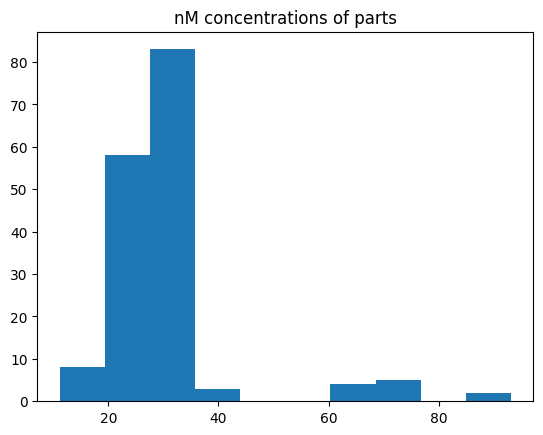

In [5]:
plt.hist(echo_parts_df["concentration (nM)"])
plt.title("nM concentrations of parts")

In [6]:
echo_parts_df[echo_parts_df.isna().any(axis=1)]

,plate,well,m_id,concentration (ng/uL),mut_str,length,type,concentration (nM),MW (ng/fmol)
161,3,B2,m211,500.0,None,8264,bb,93.08,5.3716
162,3,B3,m212,500.0,None,8270,bb,93.01,5.3755


In [7]:
# make a dictionary of mutants to mids of our parts
mut_map_dict = echo_parts_df[["m_id", "mut_str"]].set_index("mut_str")["m_id"].to_dict()
mut_map_dict.pop(None)
len(mut_map_dict)

161

In [8]:
echo_parts_df = echo_parts_df.set_index("m_id")

In [9]:
positions_list = dms_input_df["position_1_idx"].unique().tolist()
positions_list

[14, 27, 81, 174, 185, 191, 253, 295]

In [10]:
def convert_to_association_df(master_parts_df, parts_list, backbone, out_well, rxn_vol=3, part_nM=4):
    """Takes in a list of parts. Each list should have the number of inserts to the vector. 
    A backbone plasmid must also be designated as an mID.

    Parameters
    ----------
    master_parts_df:
        A dataframe with all the parts (with mIDs) and their concentrations in ng/ul
    parts_list: list
        A list of mids (str) for inserts in the reaction
    backbone: str
        mid for the backbone the inserts will be going into
    out_well: str
        Name of the destination well where the reaction will take place

    Returns
    -------
    pd.DataFrame()
        Dataframe or series with the nM value needed in the output well
    
    """
    df = pd.DataFrame(master_parts_df.copy().index)
    df= df.set_index("m_id")

    df[f"{out_well} (nM)"] = 0.0
    df[f"{out_well} (uL)"] = 0.0
    
    for part in parts_list:
        df.at[part, f"{out_well} (nM)"] = part_nM
        df.at[part, f"{out_well} (uL)"] = part_nM * rxn_vol/master_parts_df.at[part, "concentration (nM)"] #rxn_vol * 0.1 * 40/master_parts_df.at[part, "concentration (nM)"] 
    
    df.at[backbone, f"{out_well} (nM)"] = part_nM/2
    df.at[backbone, f"{out_well} (uL)"] = part_nM/2 * rxn_vol/master_parts_df.at[part, "concentration (nM)"] #rxn_vol * 0.05 * 40 / float(master_parts_df.at[backbone, "concentration (nM)"])
    print(df[df[f"{out_well} (uL)"] != 0.0][f"{out_well} (uL)"].to_dict())
    
    parts_vol = df[f"{out_well} (uL)"].sum()
    
    mm_multiplier = part_nM/4

    T4_buffer = 0.1 * rxn_vol * 1.1
    T4_ligase = 0.1 * rxn_vol * 1.1
    enzyme = 0.05 * rxn_vol * 1.1
    
    mm_vol = T4_buffer + T4_ligase + enzyme
    print(mm_vol)
    print(mm_vol + df[f"{out_well} (uL)"].sum())

    df = df[df[f"{out_well} (nM)"] != 0][[f"{out_well} (nM)"]].reset_index()
    df_T = df.transpose()
    df_T.columns = [f"component_{i+1}" for i in range(len(df))]

    out_df = df_T.copy()

    inserts = [f"{col} (nM)" for col in df_T.columns]
    # Insert each component column into the DataFrame
    for i, insert in enumerate(inserts, start=1):
        out_df.insert(i * 2 - 1, insert, df_T.iloc[1, i-1])

    out_df = out_df.iloc[0:1,:]
    out_df = out_df.rename(index={"m_id": out_well})
    
    return out_df

def convert_to_association_df_volumes(master_parts_df, parts_list, backbone, out_well, rxn_vol=3, part_nM=4):
    """Takes in a list of parts. Each list should have the number of inserts to the vector. 
    A backbone plasmid must also be designated as an mID.

    Parameters
    ----------
    master_parts_df:
        A dataframe with all the parts (with mIDs) and their concentrations in ng/ul
    parts_list: list
        A list of mids (str) for inserts in the reaction
    backbone: str
        mid for the backbone the inserts will be going into
    out_well: str
        Name of the destination well where the reaction will take place
    rxn_vol: float
        Final volume of reaction
    part_nM : float
        Final concentration of part in the reaction (not used for volumes version of script.)


    Returns
    -------
    pd.DataFrame()
        Dataframe or series with the nM value needed in the output well
    
    """
    transfer_vol = 0.1 * rxn_vol * 0.87

    df = pd.DataFrame(master_parts_df.copy().index)
    df= df.set_index("m_id")

    df[f"{out_well} (nM)"] = 0.0
    df[f"{out_well} (uL)"] = 0.0
    
    part_concentrations_list = []
    for part in parts_list:
        
        if master_parts_df.at[part, "concentration (nM)"] >= 40:
            part_conc =  part_nM
            df.at[part, f"{out_well} (nM)"] = part_conc
            df.at[part, f"{out_well} (uL)"] = part_nM * rxn_vol/master_parts_df.at[part, "concentration (nM)"]

            part_concentrations_list.append(part_conc)
        
        else:
            
            part_conc = np.round(master_parts_df.at[part, "concentration (nM)"] * transfer_vol / rxn_vol, 2)
            df.at[part, f"{out_well} (nM)"] = part_conc
            df.at[part, f"{out_well} (uL)"] = transfer_vol

            part_concentrations_list.append(part_conc)

    avg_part_conc = np.round(np.mean(part_concentrations_list), 2)
    
    df.at[backbone, f"{out_well} (nM)"] = avg_part_conc/2
    df.at[backbone, f"{out_well} (uL)"] = avg_part_conc/2 * rxn_vol/master_parts_df.at[part, "concentration (nM)"]
    #print(df[df[f"{out_well} (uL)"] != 0.0][f"{out_well} (uL)"].to_dict())
    
    parts_vol = df[f"{out_well} (uL)"].sum()
    
    mm_multiplier = part_nM/4

    T4_buffer = 0.1 * rxn_vol
    T4_ligase = 0.1 * rxn_vol
    enzyme = 0.05 * rxn_vol
    
    mm_vol = T4_buffer + T4_ligase + enzyme
    # print(mm_vol)
    # print(mm_vol + df[f"{out_well} (uL)"].sum())

    df_nM = df[df[f"{out_well} (nM)"] != 0][[f"{out_well} (nM)"]].reset_index()


    df_nM_T = df_nM.transpose()
    df_nM_T.columns = [f"component_{i+1}" for i in range(len(df_nM))]


    out_df = df_nM_T.copy()

    inserts = [f"{col} (nM)" for col in df_nM_T.columns]
    # Insert each component column into the DataFrame
    for i, insert in enumerate(inserts, start=1):
        out_df.insert(i * 2 - 1, insert, df_nM_T.iloc[1, i-1])

    out_df = out_df.iloc[0:1,:]
    out_df = out_df.rename(index={"m_id": out_well})


    df_L = df[df[f"{out_well} (nM)"] != 0][[f"{out_well} (uL)"]].reset_index()

    df_L_T = df_L.transpose()
    df_L_T.columns = [f"component_{i+1}" for i in range(len(df_L))]

    out_df_liq = df_L_T.copy()

    inserts = [f"{col} (uL)" for col in df_L_T.columns]
    # Insert each component column into the DataFrame
    for i, insert in enumerate(inserts, start=1):
        out_df_liq.insert(i * 2 - 1, insert, df_L_T.iloc[1, i-1])

    out_df_liq = out_df_liq.iloc[0:1,:]
    out_df_liq = out_df_liq.rename(index={"m_id": out_well})
    out_df_liq["master_mix"] = "mm"
    out_df_liq["master_mix (uL)"] = mm_vol
    
    return out_df, out_df_liq


def mutants_to_mids(mut_list, mut_mid_mapping):
    """Takes in a list of mutations and maps them to mIDs with the corresponding
    parts.

    Parameters
    ----------
    mut_list: list
        List of mutations (str)
    
    mut_mid_mapping: dict
        Dictionary of mutations and what mID part contains that mutation.

    Returns
    -------
    list
        A list of mIDs that will make the mutation
    """
    output_list = []
    for mut in mut_list:
        output_list.append(mut_mid_mapping[mut])
    return output_list

def add_wt_mut(mut_list, positions_list, wt_protein_seq):
    """Adds in wildtype mutations to mut_list for downstream purposes
    
    Parameters
    ----------
    mut_list: list
        A list of mutations (str), may be incomplete or empty
    
    positions_list: list
        List of positions (int) where the mutations will occur on the protein (1-indexed).
    
    wt_protein_seq: str
        The wt protein sequence. No stop codon. Start methionine should be included.

    Returns
    -------
    list
        List of mutations (str) with added wildtye mutation strings as needed.

    """
    output_list = []
    positions_current = [int(pos[1:-1]) for pos in mut_list]

    mut_current_dict = {}
    for i, p in enumerate(positions_current):
        mut_current_dict[p] = mut_list[i]
    
    for i, pos in enumerate(positions_list):

        if pos in positions_current:
            output_list.append(mut_current_dict[pos])
            continue
        else:
            wt_mut = wt_protein_seq[pos-1] + str(pos) + wt_protein_seq[pos-1]
            output_list.append(wt_mut)

    return output_list

In [11]:
0.1/1.1 * 3 

0.2727272727272727

In [12]:
association_spread_sheet_nM = pd.DataFrame()
association_spread_sheet_liq = pd.DataFrame()

for index, row in picked_mutants_df.iterrows():
    new_line_nM, new_line_liq = convert_to_association_df_volumes(master_parts_df=echo_parts_df,
                          parts_list = mutants_to_mids(row[:].tolist(), mut_map_dict),
                          backbone = "m212",
                          out_well="H1",
                          rxn_vol=3,
                          part_nM=4)
    
    association_spread_sheet_nM = pd.concat([association_spread_sheet_nM, new_line_nM], ignore_index=True)
    association_spread_sheet_liq = pd.concat([association_spread_sheet_liq, new_line_liq], ignore_index=True)

association_spread_sheet_liq["final_volume"] =  association_spread_sheet_liq.select_dtypes(include='number').sum(axis=1)

In [13]:
association_spread_sheet_liq["component_9 (uL)"].max()

np.float64(0.2787212787212787)

In [14]:
association_spread_sheet_liq["final_volume"].max()

np.float64(2.996794788273616)

In [15]:
association_spread_sheet_liq.head()

,component_1,component_1 (uL),component_2,component_2 (uL),component_3,component_3 (uL),component_4,component_4 (uL),component_5,component_5 (uL),...,component_6 (uL),component_7,component_7 (uL),component_8,component_8 (uL),component_9,component_9 (uL),master_mix,master_mix (uL),final_volume
0,m266,0.261,m214,0.172389,m216,0.181269,m218,0.170891,m219,0.167317,...,0.178306,m221,0.171355,m222,0.171994,m212,0.082342,mm,0.75,2.306864
1,m284,0.261,m214,0.172389,m215,0.175490,m218,0.170891,m219,0.167317,...,0.178306,m221,0.171355,m222,0.171994,m212,0.078902,mm,0.75,2.297645
2,m305,0.261,m214,0.172389,m215,0.175490,m216,0.181269,m219,0.167317,...,0.178306,m221,0.171355,m222,0.171994,m212,0.079547,mm,0.75,2.308667
3,m245,0.261,m215,0.175490,m216,0.181269,m218,0.170891,m219,0.167317,...,0.178306,m221,0.171355,m222,0.171994,m212,0.081052,mm,0.75,2.308675
4,m359,0.261,m214,0.172389,m215,0.175490,m216,0.181269,m218,0.170891,...,0.167317,m220,0.178306,m222,0.171994,m212,0.083202,mm,0.75,2.311858


In [16]:
association_spread_sheet_nM.sort_values(by = "component_1 (nM)")

,component_1,component_1 (nM),component_2,component_2 (nM),component_3,component_3 (nM),component_4,component_4 (nM),component_5,component_5 (nM),component_6,component_6 (nM),component_7,component_7 (nM),component_8,component_8 (nM),component_9,component_9 (nM)
117,m254,0.98,m214,4.00,m216,4.0,m218,4.0,m219,4.0,m220,4.0,m221,4.0,m222,4.0,m212,1.810
1,m284,1.35,m214,4.00,m215,4.0,m218,4.0,m219,4.0,m220,4.0,m221,4.0,m222,4.0,m212,1.835
67,m302,1.44,m339,2.01,m214,4.0,m215,4.0,m216,4.0,m219,4.0,m221,4.0,m222,4.0,m212,1.715
21,m302,1.44,m214,4.00,m215,4.0,m216,4.0,m219,4.0,m220,4.0,m221,4.0,m222,4.0,m212,1.840
66,m302,1.44,m321,1.78,m214,4.0,m215,4.0,m216,4.0,m220,4.0,m221,4.0,m222,4.0,m212,1.700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,m359,2.97,m386,2.96,m214,4.0,m215,4.0,m216,4.0,m218,4.0,m219,4.0,m220,4.0,m212,1.870
118,m373,3.04,m214,4.00,m215,4.0,m216,4.0,m218,4.0,m219,4.0,m220,4.0,m221,4.0,m212,1.940
129,m236,3.06,m215,4.00,m216,4.0,m218,4.0,m219,4.0,m220,4.0,m221,4.0,m222,4.0,m212,1.940
127,m252,3.14,m215,4.00,m216,4.0,m218,4.0,m219,4.0,m220,4.0,m221,4.0,m222,4.0,m212,1.945


In [17]:
# we are going to assume that our buffers and enzymes are at a concentration of 1 nM
association_spread_sheet_nM["component_10"] = "t4_buffer"
association_spread_sheet_nM["component_10 (nM)"] = 0.1
association_spread_sheet_nM["component_11"] = "t4_ligase"
association_spread_sheet_nM["component_11 (nM)"] = 0.1
association_spread_sheet_nM["component_12"] = "enzyme"
association_spread_sheet_nM["component_12 (nM)"] = 0.05


In [18]:
association_spread_sheet_nM.to_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/inputs/384_rluc_assem_associations.csv")

In [19]:
echo_parts_df

,plate,well,concentration (ng/uL),mut_str,length,type,concentration (nM),MW (ng/fmol)
m_id,,,,,,,,
m235,1,A1,41.9,M14A,2210,mut,29.17,1.43650
m236,1,A2,50.6,M14R,2210,mut,35.22,1.43650
m237,1,A3,40.4,M14N,2210,mut,28.12,1.43650
m238,1,A4,48.0,M14D,2210,mut,33.41,1.43650
m239,1,A5,40.5,M14C,2210,mut,28.19,1.43650
...,...,...,...,...,...,...,...,...
m221,3,A7,100.0,M253M,2197,wt,70.03,1.42805
m222,3,A8,100.0,M295M,2205,wt,69.77,1.43325
m217,3,B1,100.0,E144Y,2324,mut,66.20,1.51060


In [20]:
format_384=pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/data/rluc_384_well_plate_test.csv")[["Well Address 384", "Sample Name"]]

format_384 = format_384.rename(columns = {"Well Address 384" : "Location", "Sample Name": "Name"})

format_384 = format_384[format_384["Name"] != "0"]

format_384 = format_384.merge(echo_parts_df.reset_index()[["m_id", "concentration (nM)"]], how = "left", left_on="Name", right_on="m_id").drop(columns = ["m_id"])

format_384 = format_384.rename(columns = {"concentration (nM)" : "Concentration"})

format_384["Concentration"] = format_384["Concentration"].fillna(1.0)
format_384["Concentration"] = format_384["Concentration"].round(2)

format_384["Length"] = 0
format_384["Units"] = "nM"

for index, row in format_384.iterrows():
    if row["Name"] == "water":
        format_384.at[index, "Units"] = "x"


In [21]:
format_384.to_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/inputs/384_echo_source_wells.csv")

# Clear the source plate

In [22]:
df = pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/inputs/source_plate.dat", delimiter=' ', header=None)
df = df.iloc[0:0]
df.to_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/inputs/source_plate.dat", index=False, header=False)

EmptyDataError: No columns to parse from file

# Generate the Echo Output Sheet

In [23]:
#relevent input and output files

stock_file = os.path.join("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/inputs/384_echo_source_wells.csv")
assoc_pre_file = os.path.join("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/inputs/384_rluc_assem_associations.csv")
assoc_name = os.path.join("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/outputs/384_well_rluc_echo_outputs.csv")
plate_file  = os.path.join("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250317_rluc_dev/inputs/source_plate.dat") 

### Add materials to source plate

In [ ]:
# make our materials and add them to a source plate using the SourcePlate objects and EchoSourceMaterial objects

# read in the source plate file
source_plate_df = pd.read_csv(stock_file)

#create a source well plate object
source_well_plate = mt_echo.SourcePlate(filename = plate_file, SPtype='384PP_Plus_AQ_BP', SPname="384_source_c1", reuse_wells=True)

# iterate over the source plate file rows and create materials. Then add those materials to a well in the source plate instance.
for index, row in source_plate_df.iterrows():
   source_well_plate.add_material_to_well(well=row.Location, material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units), volume=65000)
   print(row.Location)
   
# create the EchoRun experiment with our source plate instance.
assoc_echo_calculator = mt_echo.EchoRun(DPtype= "384 Plate", plate=source_well_plate)

# make the materials in the experiment known
materials_df = source_plate_df.copy()
materials_df = materials_df.drop_duplicates("Name")

for index, row in materials_df.iterrows():
   assoc_echo_calculator.add_material(material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units))

A16
A18
A20
A22
A24
B1
B2
B3
B4
B5
B6
B7
B8
B9
B10
B11
B12
B13
B14
B15
B16
B17
B19
B21
B22
B23
B24
C16
C18
C20
C22
C24
D1
D2
D3
D4
D5
D6
D7
D8
D9
D10
D11
D12
D13
D14
D15
D16
D17
D19
D21
D22
D23
D24
E16
E18
E20
E22
E24
F1
F2
F3
F4
F5
F6
F7
F8
F9
F10
F11
F12
F13
F14
F15
F16
F17
F19
F21
F22
F23
F24
G16
G18
G20
G24
H1
H2
H3
H4
H5
H6
H7
H8
H9
H10
H11
H12
H13
H14
H15
H16
H17
H19
H21
H23
H24
I16
I18
I20
I24
J1
J2
J3
J4
J5
J6
J7
J8
J9
J10
J11
J12
J13
J14
J15
J16
J17
J19
J21
J23
J24
K16
K18
K20
K24
L1
L2
L3
L4
L5
L6
L7
L8
L9
L10
L11
L12
L13
L14
L15
L16
L17
L19
L21
L23
L24
M16
M18
M20
M24
N1
N2
N3
N4
N5
N6
N7
N8
N9
N10
N11
N12
N13
N14
N15
N16
N17
N19
N21
N23
N24
O16
O18
O20
O24
P1
P2
P3
P4
P5
P6
P7
P8
P9
P10
P11
P12
P13
P14
P15
P16
P17
P19
P21
P23
P24


In [ ]:
assoc_echo_calculator.rxn_vol = 3000 # PCR is large-volume!

# Define which column of the source file is what
name_col  = 1
conc_col  = 2
len_col   = 3
well_col  = 0
plate_col = 4